In [1]:
# Compute pairwise correlation of daily returns for 10 selected funds. Display as a Seaborn heatmap.

In [2]:
import pandas as pd

nav_df = pd.read_csv(
    "../data/processed/02_nav_history_clean.csv",
    parse_dates=["date"]
)

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

In [3]:
nav_df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [9]:
nav_df = nav_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [10]:
nav_df.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [15]:
select_schemes = nav_df['scheme_name'].unique()[:10]
select_schemes

<StringArray>
[         'HDFC Top 100 Fund - Regular Plan - Growth',
       'HDFC Short Term Debt Fund - Regular - Growth',
 'HDFC Mid-Cap Opportunities Fund - Regular - Growth',
      'ABSL Frontline Equity Fund - Regular - Growth',
             'ABSL Small Cap Fund - Regular - Growth',
                'ABSL Liquid Fund - Regular - Growth',
         'UTI Nifty 50 Index Fund - Regular - Growth',
                'UTI Mid Cap Fund - Regular - Growth',
              'UTI Flexi Cap Fund - Regular - Growth',
     'Nippon India Large Cap Fund - Regular - Growth']
Length: 10, dtype: str

In [17]:
nav_10 = nav_df[nav_df['scheme_name'].isin(select_schemes)].copy()
nav_10.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [19]:
pivot_df = nav_10.pivot(
    index = 'date',
    columns = 'scheme_name',
    values = 'nav'
)
pivot_df.head()

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,Nippon India Large Cap Fund - Regular - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth,UTI Nifty 50 Index Fund - Regular - Growth
date,,,,,,,,,,
2022-01-03,305.0996,310.7415,38.5736,107.3758,26.3169,520.4608,42.8339,191.0721,119.2905,89.8728
2022-01-04,305.4514,310.6977,38.1545,105.9447,26.2234,515.0971,42.8033,189.0737,120.6402,90.8724
2022-01-05,306.6324,310.8165,38.1775,105.4800,26.2221,521.7239,43.0564,188.0701,121.4580,90.1565
2022-01-06,305.9800,310.7719,37.0665,104.9350,26.1728,515.7880,43.2088,190.4545,125.2386,91.5338
2022-01-07,304.0480,310.8388,37.9845,104.3318,26.2261,515.1639,42.9585,187.3124,124.1321,90.6762


In [22]:
# calculate daily returns
daily_returns = pivot_df.pct_change().dropna()
daily_returns.head()

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,Nippon India Large Cap Fund - Regular - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth,UTI Nifty 50 Index Fund - Regular - Growth
date,,,,,,,,,,
2022-01-04,0.001153,-0.000141,-0.010865,-0.013328,-0.003553,-0.010306,-0.000714,-0.010459,0.011314,0.011122
2022-01-05,0.003866,0.000382,0.000603,-0.004386,-0.000050,0.012865,0.005913,-0.005308,0.006779,-0.007878
2022-01-06,-0.002128,-0.000143,-0.029101,-0.005167,-0.001880,-0.011377,0.003540,0.012678,0.031127,0.015277
2022-01-07,-0.006314,0.000215,0.024766,-0.005748,0.002036,-0.001210,-0.005793,-0.016498,-0.008835,-0.009369
2022-01-10,0.011548,0.000690,0.001251,0.006277,0.006791,-0.008639,0.006360,-0.011593,-0.000722,-0.001202


In [23]:
correlation_matrix = daily_returns.corr()
correlation_matrix

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,Nippon India Large Cap Fund - Regular - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth,UTI Nifty 50 Index Fund - Regular - Growth
scheme_name,,,,,,,,,,
ABSL Frontline Equity Fund - Regular - Growth,1.000000,-0.027230,0.010202,-0.018079,0.023769,0.027747,-0.005432,-0.006490,0.007229,0.001570
ABSL Liquid Fund - Regular - Growth,-0.027230,1.000000,-0.007530,0.007864,0.018455,-0.033773,0.003507,0.036547,0.014307,-0.001436
ABSL Small Cap Fund - Regular - Growth,0.010202,-0.007530,1.000000,0.000351,-0.006710,0.016053,0.043384,0.002304,0.004860,-0.005929
HDFC Mid-Cap Opportunities Fund - Regular - Growth,-0.018079,0.007864,0.000351,1.000000,0.002150,-0.000006,-0.013318,-0.036647,-0.018166,-0.034228
HDFC Short Term Debt Fund - Regular - Growth,0.023769,0.018455,-0.006710,0.002150,1.000000,0.045567,-0.014166,-0.005648,0.013754,-0.001038
HDFC Top 100 Fund - Regular Plan - Growth,0.027747,-0.033773,0.016053,-0.000006,0.045567,1.000000,-0.026781,-0.023316,-0.005867,-0.093533
Nippon India Large Cap Fund - Regular - Growth,-0.005432,0.003507,0.043384,-0.013318,-0.014166,-0.026781,1.000000,0.001248,-0.039886,-0.000285
UTI Flexi Cap Fund - Regular - Growth,-0.006490,0.036547,0.002304,-0.036647,-0.005648,-0.023316,0.001248,1.000000,-0.007865,-0.036704
UTI Mid Cap Fund - Regular - Growth,0.007229,0.014307,0.004860,-0.018166,0.013754,-0.005867,-0.039886,-0.007865,1.000000,0.020691


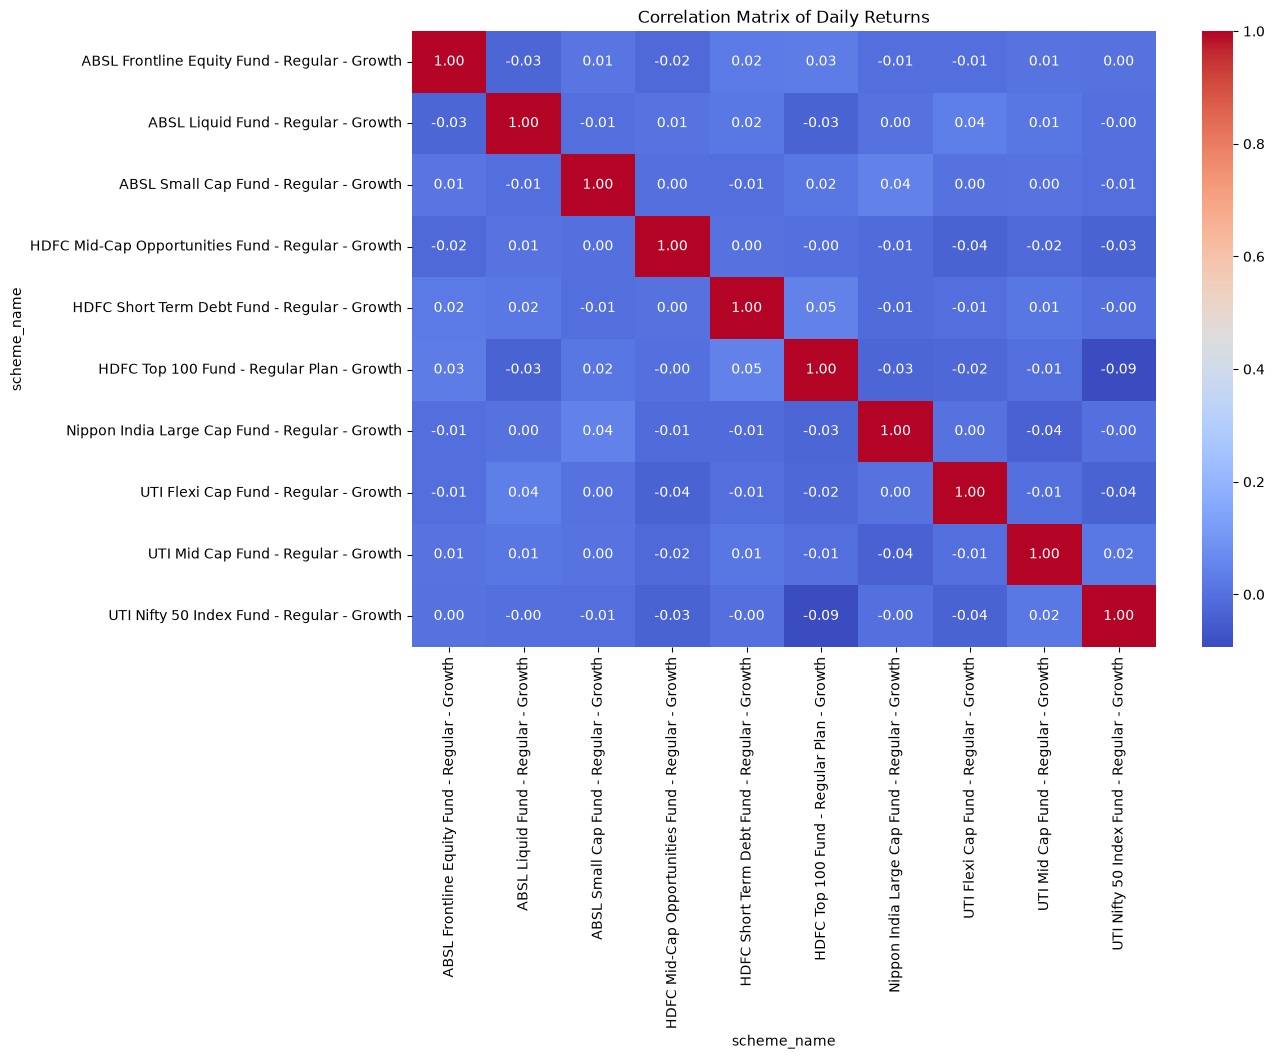

In [26]:
# heatmap
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot = True,
    cmap='coolwarm',
    fmt = ".2f"

)
plt.title("Correlation Matrix of Daily Returns")
plt.show()